##### Columns Description :
###### 1. Time : Time elapsed between first transaction in dataset
###### 2. v1-v28 : Anonymised Feature obtain using PCA Transformation
###### 3. Amount : Transaction Amount
###### 4. Class : taget Variable (0-non fraud, 1-fraud)

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [34]:
credit_card = pd.read_csv('creditcard.csv')
card = credit_card.copy()
card.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [35]:
card.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [36]:
card['Class'].value_counts(normalize=True)*100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

###### Dataset highly imbalanced with fraud transaction representing less than 1%

<Axes: xlabel='Amount', ylabel='Count'>

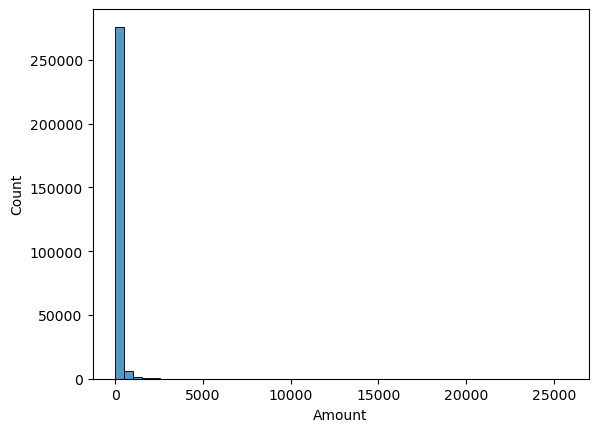

In [37]:
sns.histplot(data=card,x='Amount',bins=50)

<Axes: xlabel='Time', ylabel='Count'>

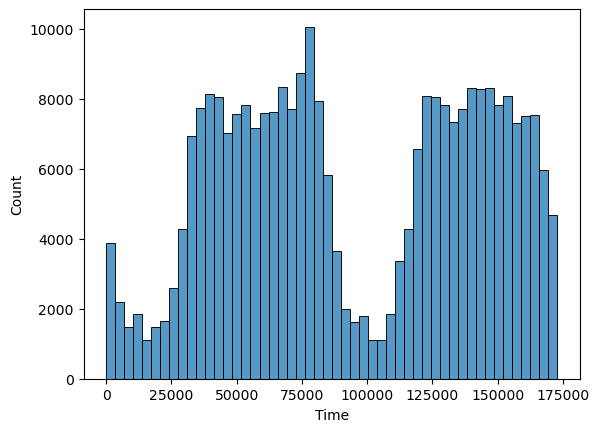

In [38]:
sns.histplot(data=card,x='Time',bins=50)

In [39]:
card['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [40]:
card.groupby('Class')[['Amount']].describe()

Amount                                                            
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87

In [41]:
card['Time'].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

In [42]:
card.groupby('Class')[['Time']].describe()

Time                                                       \
          count          mean           std    min      25%      50%   
Class                                                                  
0      284315.0  94838.202258  47484.015786    0.0  54230.0  84711.0   
1         492.0  80746.806911  47835.365138  406.0  41241.5  75568.5   

                           
            75%       max  
Class                      
0      139333.0  172792.0  
1      128483.0  170348.0

###### Fraud Transaction are spread across different time interval, indicating no fixed fraud time window

In [43]:
card.groupby('Class')[['Amount']].mean()

,Amount
Class,
0,88.291022
1,122.211321


In [44]:
card.groupby('Class')[['Amount']].median()

,Amount
Class,
0,22.00
1,9.25


###### Fraud transaction generally involve smaller amount compared to non-fraud transaction

In [45]:
card[['V1','V2','V3','V4','V5']].describe()

,V1,V2,V3,V4,V5
count,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05
mean,1.759061e-12,-8.251130e-13,-9.654937e-13,8.321385e-13,1.649999e-13
std,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00
min,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02
25%,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01
50%,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02
75%,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01
max,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01


###### PCA Features show different stastical distribution for fraud and non- fraud

In [46]:
card['Amount'].quantile([0.95,0.99])

0.95     365.00
0.99    1017.97
Name: Amount, dtype: float64

###### Highly Amount transaction are rare and may indicates potential anomalies

##### Insights :
###### 1.The dataset contains anonimized credit card transaction.
###### 2.Features "v1-v28" are PCA transformed for privacy.
###### 3.The target Variable is highly imbalanced with less than 1% fraud cases.
###### 4.Fraud transaction generally involves small amount.
###### 5.Accuracy is not reliable metric, recall is prioritize to minimize fraud loss.

###### Model BUilding

In [54]:
card.head(1)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Scaled_Amount,Scaled_Time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583


###### Scaling 

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
card['Scaled_Amount'] = scaler.fit_transform(card[['Amount']])
card['Scaled_Time'] = scaler.fit_transform(card[['Time']])

In [53]:
card.drop(['Amount','Time'],axis=1,inplace=True)

In [55]:
X = card.drop('Class',axis=1)
y = card[['Class']]

In [56]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
from sklearn.linear_model import LogisticRegression

In [57]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)

C:\Users\admin\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=1000)

In [58]:
y_pred = lr.predict(X_test)

###### Evaluation metrix

In [63]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred),"\n\n")
print(classification_report(y_test,y_pred))

[[56851    13]
 [   35    63]] 


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



##### The model performs extremely well on non-fraud transaction due to class imbalanced.However, the recall for fraud class is only 0.64,meaning a sifnificant number of fraudlent transaction are missed.
##### improve fraud recall is critical to reduce financial loss

In [64]:
lr_bal = LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42)
lr_bal.fit(X_train,y_train)

C:\Users\admin\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [65]:
y_perd_bal = lr_bal.predict(X_test)

###### Evaluation

In [66]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_perd_bal),"\n\n")
print(classification_report(y_test,y_perd_bal))

[[55475  1389]
 [    8    90]] 


              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



#### using threshold Tuning

In [68]:
y_prob = lr_bal.predict_proba(X_test)[:,1]
# lower threshold
y_pred_thresh = (y_prob>0.2).astype(int)

from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred_thresh),"\n\n")
print(classification_report(y_test,y_pred_thresh))

[[51332  5532]
 [    6    92]] 


              precision    recall  f1-score   support

           0       1.00      0.90      0.95     56864
           1       0.02      0.94      0.03        98

    accuracy                           0.90     56962
   macro avg       0.51      0.92      0.49     56962
weighted avg       1.00      0.90      0.95     56962



#### USing SMOT

In [69]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
x_sm,y_sm = sm.fit_resample(X_train,y_train)
lr_sm = LogisticRegression(max_iter=1000)
lr_sm.fit(x_sm,y_sm)

y_pred_sm = lr_sm.predict(X_test)



from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred_sm),"\n\n")
print(classification_report(y_test,y_pred_sm))

C:\Users\admin\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[[55406  1458]
 [    8    90]] 


              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



#### Conclusion:
##### A threshold-based Logistic Regression model was implemented to handle extreme class imbalance in credit card fraud data. 
##### By lowering the classification threshold to 0.2, the model achieved a recall of 94% for fraudulent transactions, 
##### ensuring that the majority of fraud cases were successfully detected.

##### Although precision decreased due to an increase in false positives, this trade-off is acceptable in real-world 
##### financial systems where missing a fraud transaction is more costly than incorrectly flagging a legitimate one.
